In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [35]:
X,y=make_regression(n_samples=200,n_features=3,noise=10,random_state=42)
print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (200, 3)
Shape of y: (200,)


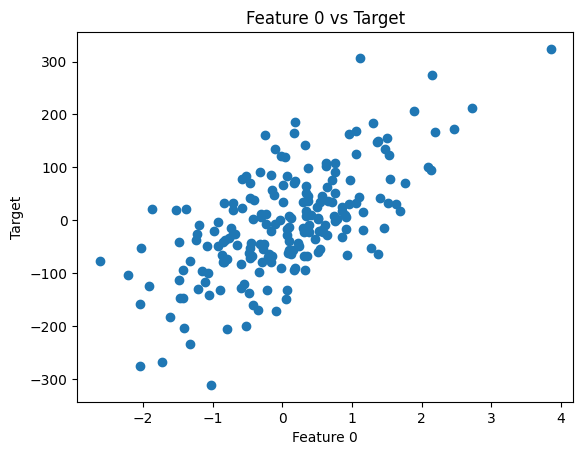

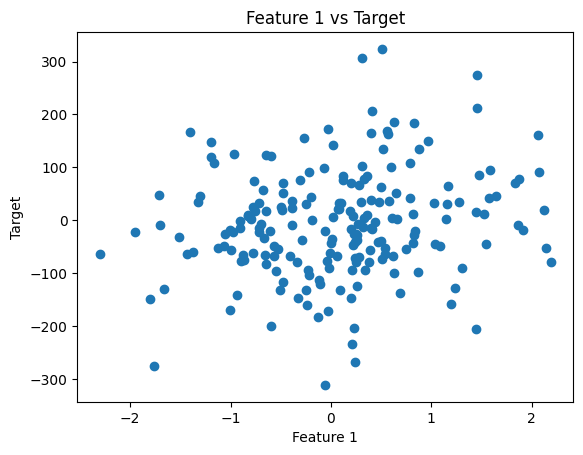

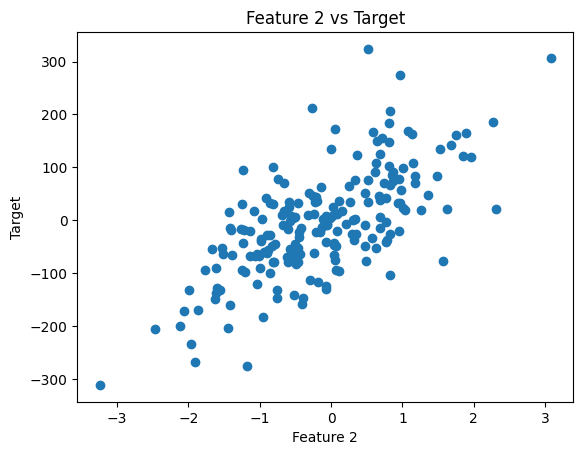

In [36]:
for i in range(3):
    plt.scatter(X[:,i],y)
    plt.xlabel(f"Feature {i}")
    plt.ylabel(f"Target")
    plt.title(f"Feature {i} vs Target")
    plt.show()

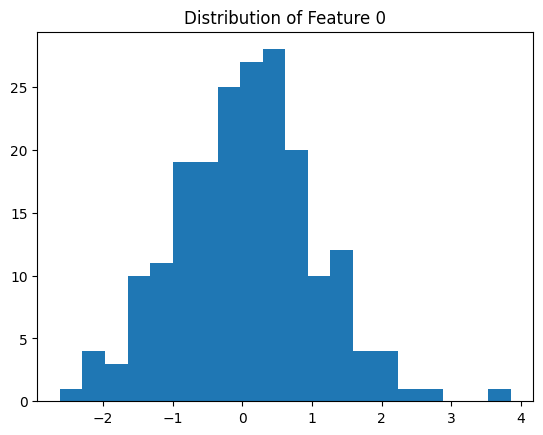

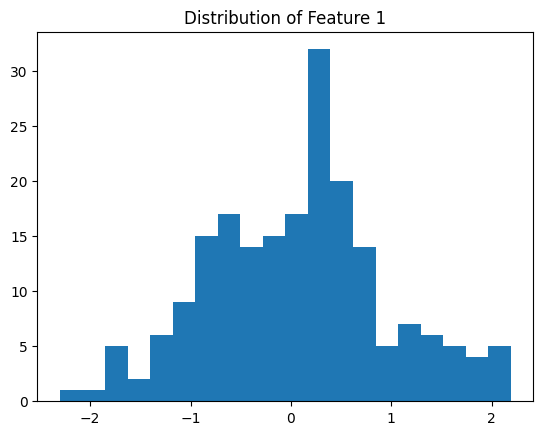

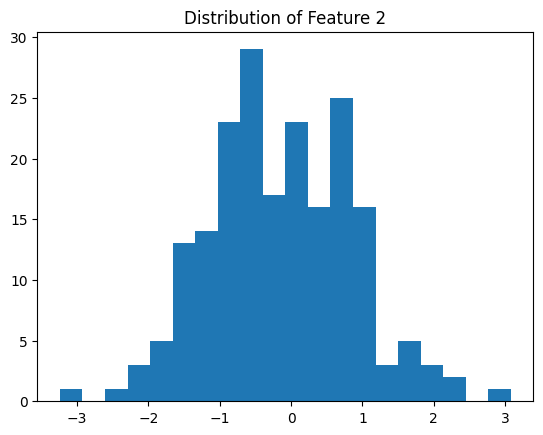

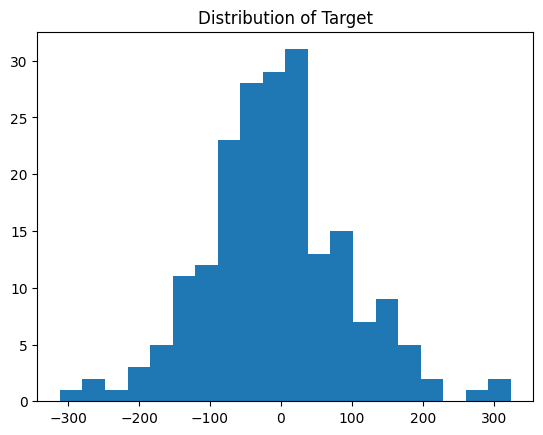

In [37]:
for i in range(3):
    plt.hist(X[:,i],bins=20)
    plt.title(f"Distribution of Feature {i}")
    plt.show()
plt.hist(y,bins=20)
plt.title("Distribution of Target")
plt.show()

In [38]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled=np.c_[np.ones(X_scaled.shape[0]),X_scaled]

In [39]:
def gradient_descent(X, y, eta=0.01, n_iter=1000):
    m = len(y)                     # Number of samples
    cost_history = []               # To store cost at each iteration
    theta = np.zeros(X.shape[1])   # Initialize theta (weights) as zeros

    for i in range(n_iter):
        prediction = X.dot(theta)             # Predicted y values
        error = prediction - y                # Difference between predicted and actual
        grad = (1/m) * X.T.dot(error)        # Compute gradients
        theta = theta - eta * grad           # Update weights
        cost = (1/(2*m)) * np.sum(error**2)  # Compute Mean Squared Error cost
        cost_history.append(cost)            # Save cost for plotting

    return theta, cost_history

In [48]:
theta,cost_history = gradient_descent(X_scaled,y)
print("Coefficent of Gradient descent")
print(theta)
print(cost_history)

Coefficent of Gradient descent
[-6.5468808  71.89995328 19.46501945 72.83453223]
[np.float64(5112.8183003907425), np.float64(5019.313889393081), np.float64(4927.538296104946), np.float64(4837.459547045356), np.float64(4749.046260255009), np.float64(4662.267634348896), np.float64(4577.093437771595), np.float64(4493.493998251515), np.float64(4411.440192450373), np.float64(4330.90343580432), np.float64(4251.855672553142), np.float64(4174.269365954062), np.float64(4098.117488676727), np.float64(4023.373513376013), np.float64(3950.0114034393687), np.float64(3878.0056039054516), np.float64(3807.331032550893), np.float64(3737.9630711420696), np.float64(3669.8775568488404), np.float64(3603.0507738172273), np.float64(3537.4594448981143), np.float64(3473.0807235290686), np.float64(3409.8921857664454), np.float64(3347.871822464996), np.float64(3286.9980316022466), np.float64(3227.2496107449697), np.float64(3168.6057496551075), np.float64(3111.0460230325752), np.float64(3054.550383392406), np.floa

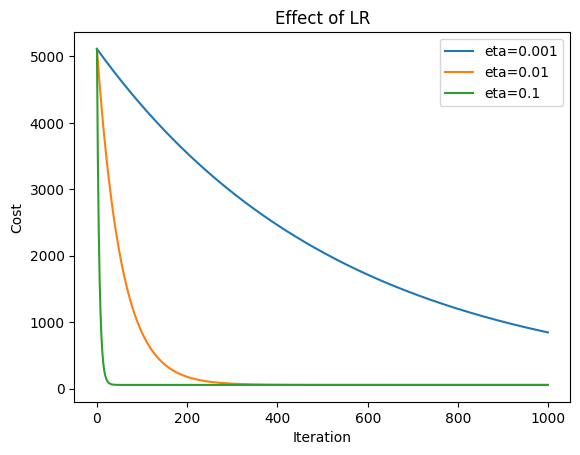

In [41]:
etas = [0.001, 0.01, 0.1]

for e in etas:
    theta_temp,cost_temp = gradient_descent(X_scaled, y, eta=e, n_iter=1000)
    plt.plot(cost_temp,label = f"eta={e}")
    #print(f"Eta = {e} -> Theta = {theta_temp}")
plt.legend()
plt.title("Effect of LR")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

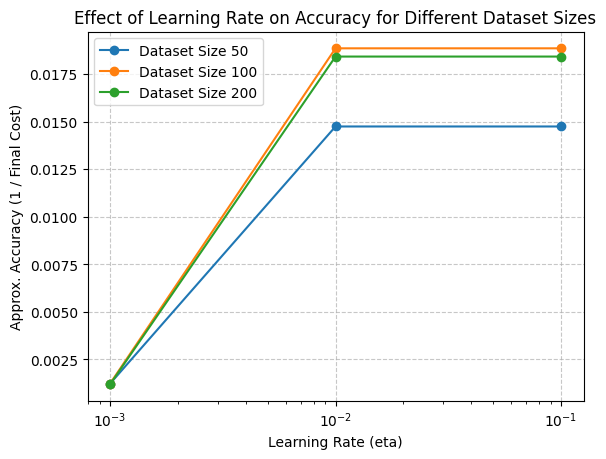

In [49]:
# Learning rates and dataset sizes
etas = [0.001, 0.01, 0.1]
sizes = [50, 100, 200]

# Store results
results = {}

for s in sizes:
    X_sub = X_scaled[:s]
    y_sub = y[:s]
    eta_costs = []
    
    for eta in etas:
        theta, cost_history = gradient_descent(X_sub, y_sub, eta=eta, n_iter=1000)
        final_cost = cost_history[-1]
        # Treat "accuracy" as inverse of cost
        eta_costs.append(1/final_cost)
    
    results[s] = eta_costs

# Plotting

for s in sizes:
    plt.plot(etas, results[s], marker='o', label=f'Dataset Size {s}')

plt.xscale('log')  # log scale for learning rate
plt.xlabel('Learning Rate (eta)')
plt.ylabel('Approx. Accuracy (1 / Final Cost)')
plt.title('Effect of Learning Rate on Accuracy for Different Dataset Sizes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [50]:
model=LinearRegression()
model.fit(X,y)
print("Sklearn Intercept:", model.intercept_)
print("Sklearn Coefficients:",model.coef_)

Sklearn Intercept: -0.36751043344601353
Sklearn Coefficients: [71.64233443 21.84558969 72.75374038]


In [51]:
from sklearn.linear_model import LinearRegression

# Fit model
model = LinearRegression()
model.fit(X_scaled, y)

# Sklearn coefficients
theta_sklearn = np.concatenate(([model.intercept_], model.coef_[1:]))  # if X_scaled includes intercept
print("Sklearn Theta:", theta_sklearn)

Sklearn Theta: [-6.54716345 71.90688717 19.46709029 72.84052324]


In [52]:
theta_gd, cost_history = gradient_descent(X_scaled, y, eta=0.01, n_iter=1000)
print("Gradient Descent Theta:", theta_gd)

Gradient Descent Theta: [-6.5468808  71.89995328 19.46501945 72.83453223]


In [53]:
for i in range(len(theta_gd)):
    print(f"Theta {i}: Gradient Descent = {theta_gd[i]:.4f}, Sklearn = {theta_sklearn[i]:.4f}")

Theta 0: Gradient Descent = -6.5469, Sklearn = -6.5472
Theta 1: Gradient Descent = 71.9000, Sklearn = 71.9069
Theta 2: Gradient Descent = 19.4650, Sklearn = 19.4671
Theta 3: Gradient Descent = 72.8345, Sklearn = 72.8405
